# **Dataset: Adult Income Dataset**

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data = fetch_openml('adult', version=2, as_frame=True)
df: pd.DataFrame = data.frame
target = 'class'  # target column name

#### **PART 1 - EXPLORATORY DATA ANALYSIS**

##### 1.) Prints the information of the original dataframe of the dataset.

In [45]:
print(df.info(), end='\n\n')

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB
None



##### 2.) Counts the value by class, then plot the imbalance ratio using bars.

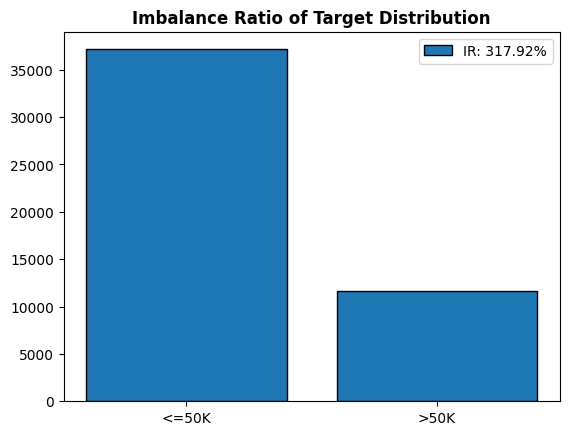

In [46]:
# 2.)
class_counts = df[target].value_counts()
plt.title('Imbalance Ratio of Target Distribution', weight='bold')
plt.bar(class_counts.index, class_counts, edgecolor='black', label=f'IR: {class_counts.max()/class_counts.min()*100:.2f}%')
plt.legend()
plt.show()

##### 3.) Selects the number features only on the original dataframe, then plot it using histogram.

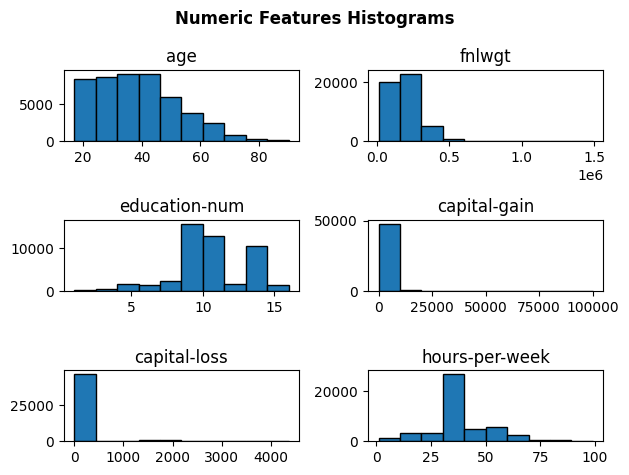

In [47]:
num_features = df.select_dtypes(include='number')
num_features.hist(grid=False, edgecolor='black')
plt.suptitle('Numeric Features Histograms', weight='bold')
plt.tight_layout()
plt.show()

##### 4.) Selects the categorical features only, then gets the top 5 most frequent categories on each categorical features.

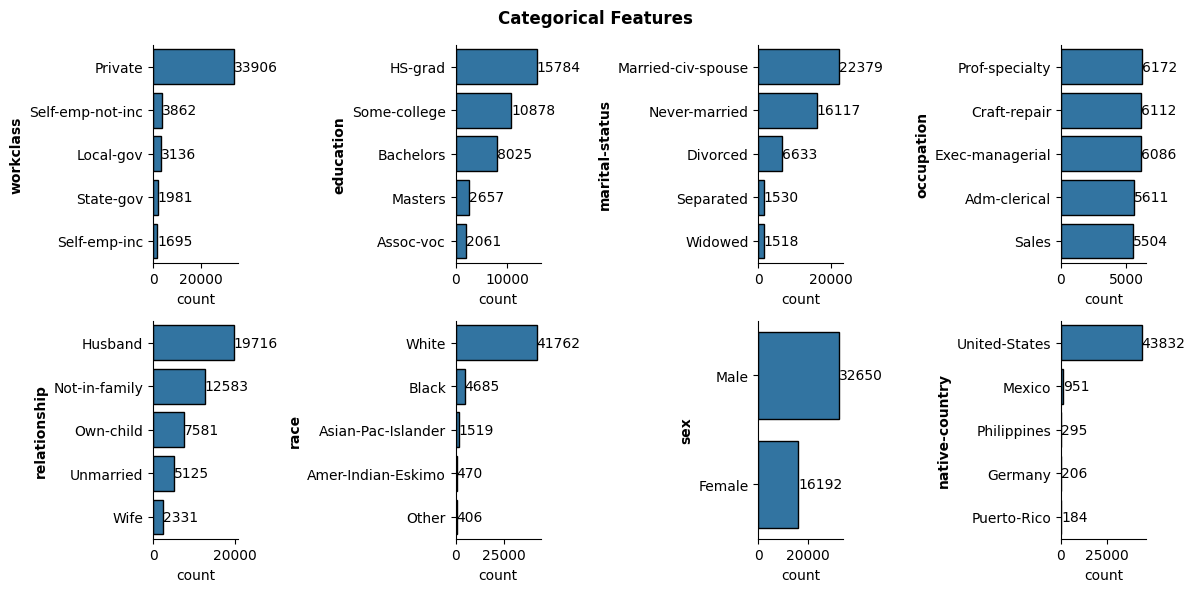

In [48]:
cat_features = df.select_dtypes(include='category')
cat_features.drop(labels='class', axis=1, inplace=True)
plt.figure(figsize=(12, 6))
plt.suptitle('Categorical Features', weight='bold')

for i, column in enumerate(cat_features.columns, start=1):
    plt.subplot(2, 4, i)
    bars = sns.countplot(data=cat_features, y=column, edgecolor='black', order=cat_features[column].value_counts().index[:5])
    bars.bar_label(bars.containers[0], labels=cat_features[column].value_counts().iloc[:5])
    bars.spines['top'].set_visible(False)
    bars.spines['right'].set_visible(False)
    plt.ylabel(column, weight='bold')

plt.tight_layout()
plt.show()

##### 5.) Plots the correlation of number features using heatmap.

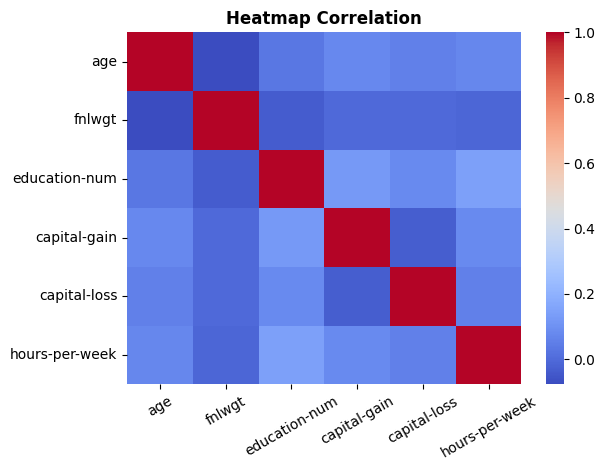

In [49]:
sns.heatmap(num_features.corr(), cmap='coolwarm')
plt.title('Heatmap Correlation', weight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##### 6.) Plots a boxplot for the number features against the target.

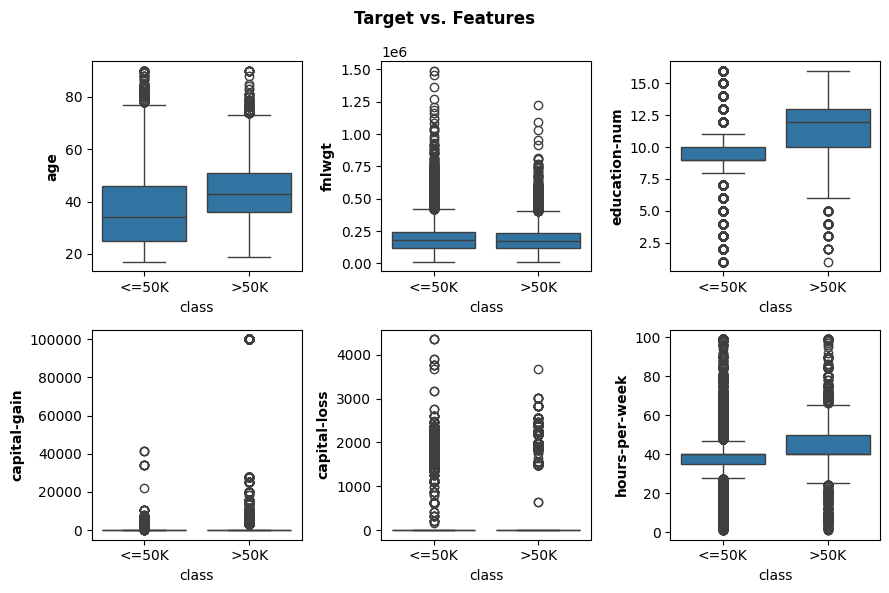

In [50]:
numf_with_target = num_features.copy()
numf_with_target['class'] = df['class']
plt.figure(figsize=(9,6))
plt.suptitle('Target vs. Features', weight='bold')

for i, column in enumerate(numf_with_target.columns[:-1], start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(numf_with_target, x='class', y=column)
    plt.ylabel(column, weight='bold')

plt.tight_layout()
plt.show()

#### **PART 2 - DATA PRE-PROCESSING**

##### 1.) Imputes the number and categorical features by using the SimpleImputer processor with a 'median' strategy for number features and 'most_frequent' strategy for categorical features.

In [ ]:
num_imputer = SimpleImputer(strategy='median')
num_imputer.set_output(transform='pandas')
df[num_features.columns] = num_imputer.fit_transform(num_features)

cat_imputer = SimpleImputer(strategy='most_frequent')
cat_imputer.set_output(transform='pandas')
df[cat_features.columns] = cat_imputer.fit_transform(cat_features)

##### 2.) Encodes the categorical features by using OneHotEncoder processor.

In [52]:
nominal_cats = cat_features.columns.to_list()
encoder = OneHotEncoder(sparse_output=False)
encoder.set_output(transform='pandas')
encoded_nominalcats = encoder.fit_transform(df[nominal_cats])
print('*ENCODED CATEGORICAL FEATURES\n', encoded_nominalcats, end='\n\n')

*ENCODED CATEGORICAL FEATURES
        workclass_Federal-gov  workclass_Local-gov  workclass_Never-worked  \
0                        0.0                  0.0                     0.0   
1                        0.0                  0.0                     0.0   
2                        0.0                  1.0                     0.0   
3                        0.0                  0.0                     0.0   
4                        0.0                  0.0                     0.0   
...                      ...                  ...                     ...   
48837                    0.0                  0.0                     0.0   
48838                    0.0                  0.0                     0.0   
48839                    0.0                  0.0                     0.0   
48840                    0.0                  0.0                     0.0   
48841                    0.0                  0.0                     0.0   

       workclass_Private  workclass_Self-emp

##### 3.) Scales the number features by using StandardScaler processor.

In [53]:
scaler = StandardScaler()
scaler.set_output(transform='pandas')
scaled_numf = scaler.fit_transform(num_features)
print('*SCALED NUM FEATURES\n', scaled_numf, end='\n\n')

*SCALED NUM FEATURES
             age    fnlwgt  education-num  capital-gain  capital-loss  \
0     -0.995129  0.351675      -1.197259     -0.144804     -0.217127   
1     -0.046942 -0.945524      -0.419335     -0.144804     -0.217127   
2     -0.776316  1.394723       0.747550     -0.144804     -0.217127   
3      0.390683 -0.277844      -0.030373      0.886874     -0.217127   
4     -1.505691 -0.815954      -0.030373     -0.144804     -0.217127   
...         ...       ...            ...           ...           ...   
48837 -0.849254  0.640492       0.747550     -0.144804     -0.217127   
48838  0.098933 -0.334178      -0.419335     -0.144804     -0.217127   
48839  1.411808 -0.357510      -0.419335     -0.144804     -0.217127   
48840 -1.213941  0.111984      -0.419335     -0.144804     -0.217127   
48841  0.974183  0.930494      -0.419335      1.871315     -0.217127   

       hours-per-week  
0           -0.034087  
1            0.772930  
2           -0.034087  
3           -0.03

##### 4.) Combines the preprocessed data then splits them into 70% training and 30% test sets, stratified by the target.

In [54]:
df_mod: pd.DataFrame = pd.concat([scaled_numf, encoded_nominalcats], axis=1)
df_mod[target] = df[target].map({'<=50K':0, '>50K':1})
X = df_mod[df_mod.columns[:-1]]
y = df_mod[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

#### **PART 3 - BUILDING BASELINE MODELS**

##### 1.) Cross-validates the splitted data with a Logistic Regression classifier and StratifiedKfold with 5 splits, then gets the results.

In [55]:
logreg = LogisticRegression(max_iter=500)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_cv_results = cross_validate(estimator=logreg, X=X_train, y=y_train, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=skfold, n_jobs=4)
cv_res_df = pd.DataFrame({'log_results':[log_cv_results['test_accuracy'].mean().round(2), log_cv_results['test_precision'].mean().round(2), log_cv_results['test_recall'].mean().round(2),
            log_cv_results['test_f1'].mean().round(2), log_cv_results['test_roc_auc'].mean().round(2)]}, index=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

##### 2.) Cross-validates the splitted data with a Random Forest classifier with the same cv from above, then gets the results and compares with the cross-validated logistic regression classifier.

In [56]:
rf_clf = RandomForestClassifier(random_state=42, n_jobs=4)
rf_cv_results = cross_validate(estimator=rf_clf, X=X_train, y=y_train, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=skfold, n_jobs=4)
cv_res_df['rf_results'] = [rf_cv_results['test_accuracy'].mean().round(2), rf_cv_results['test_precision'].mean().round(2), rf_cv_results['test_recall'].mean().round(2), rf_cv_results['test_f1'].mean().round(2), rf_cv_results['test_roc_auc'].mean().round(2)]
print('*BASELINE CLF CV RESULTS:\n', cv_res_df, end='\n\n')

*BASELINE CLF CV RESULTS:
            log_results  rf_results
accuracy          0.85        0.85
precision         0.73        0.72
recall            0.59        0.62
f1                0.65        0.66
roc_auc           0.90        0.90



##### 3.) Gets the best performing classifier from above.

In [57]:
print('Best Performing Classifier:', rf_clf, end='\n\n')

Best Performing Classifier: RandomForestClassifier(n_jobs=4, random_state=42)



#### **PART 4 - FEATURE ENGINEERING**

##### 1.) Creates two new features 'age_group' and 'capital_gain_ratio'.

In [58]:
# Groups 'age' feature
def age_grouping(x):
    if x < 39:
        return 'Young'
    elif x < 59:
        return 'Middle'
    else:
        return 'Senior'

df_mod['age_group'] = df['age'].map(age_grouping)
ag_encoded = encoder.fit_transform(df_mod['age_group'].to_frame())
df_mod[ag_encoded.columns] = ag_encoded
df_mod.drop('age_group', axis=1, inplace=True)
df_mod['capital_gain_ratio'] = df['capital-gain'] / df['hours-per-week']
df_mod[target] = df_mod.pop(target)

##### 2.) Modifies the X train and test to add the two new features, then fit to the chosen classifier to get the feature_importances and get the top 10 features of the data.

In [59]:
X_train = pd.concat([X_train, df_mod.loc[X_train.index, ag_encoded.columns], df_mod.loc[X_train.index, 'capital_gain_ratio']], axis=1)
X_test = pd.concat([X_test, df_mod.loc[X_test.index, ag_encoded.columns], df_mod.loc[X_test.index, 'capital_gain_ratio']], axis=1)

rf_clf.fit(X_train, y_train)
topf_df = pd.DataFrame({'features': df_mod.columns[:-1], 'feature_score':rf_clf.feature_importances_})
topf_df.sort_values(by='feature_score', ascending=False, inplace=True)
topf_df.drop(index=topf_df.index[10:], inplace=True)
topf_df.index = range(1, 11)
topf_df.index.name = 'rank'
print(topf_df, end='\n\n')

                               features  feature_score
rank                                                  
1                                fnlwgt       0.159510
2                                   age       0.122768
3                        hours-per-week       0.083229
4                          capital-gain       0.059813
5                         education-num       0.059382
6     marital-status_Married-civ-spouse       0.057195
7                    capital_gain_ratio       0.051332
8                  relationship_Husband       0.036781
9                          capital-loss       0.031133
10         marital-status_Never-married       0.028820



###### <span style="font-size: 1.8em;"> 2.1) Creates a new cross_validation for the 10 top features only by using the same two validation method from above then compares the scores of the two of them.</span>

In [60]:
log_cv_results = cross_validate(estimator=logreg, X=X_train[topf_df['features'].to_list()], y=y_train, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=skfold, n_jobs=4)
rf_cv_results = cross_validate(estimator=rf_clf, X=X_train[topf_df['features'].to_list()], y=y_train, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], cv=skfold, n_jobs=4)
cv_res_df = pd.DataFrame({'log_results':[log_cv_results['test_accuracy'].mean().round(2), log_cv_results['test_precision'].mean().round(2), log_cv_results['test_recall'].mean().round(2), log_cv_results['test_f1'].mean().round(2), log_cv_results['test_roc_auc'].mean().round(2)], 
    'rf_results':[rf_cv_results['test_accuracy'].mean().round(2), rf_cv_results['test_precision'].mean().round(2), rf_cv_results['test_recall'].mean().round(2), rf_cv_results['test_f1'].mean().round(2), rf_cv_results['test_roc_auc'].mean().round(2)]}, index=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

print('*NEW CLF CV RESULTS:\n', cv_res_df, end='\n\n')

*NEW CLF CV RESULTS:
            log_results  rf_results
accuracy          0.84        0.84
precision         0.72        0.69
recall            0.57        0.61
f1                0.63        0.65
roc_auc           0.90        0.89



#### **PART 5 - HYPERPARAMETER**

##### 1.) Creates a RandomizedSearchCV to tune the three hyperparameters of the chosen classifier.

In [61]:
params = {'n_estimators':[100, 200, 300, 400, 500], 'max_depth':[5, 10, 20, 30], 'min_samples_split':[5, 10, 20, 30]}
rsearch_cv = RandomizedSearchCV(estimator=rf_clf, param_distributions=params, n_iter=15, scoring='roc_auc', n_jobs=4, cv=skfold)
rsearch_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'min_samples_split': [5, 10, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_sel

##### 2.) Gets the best hyperparameters and roc_auc_score for the chosen classifier.

In [62]:
print('*Best Hyperparameters for RandomForestClassifier:\n', rsearch_cv.best_params_, end='\n\n')
print('*ROC_AUC CV SCORE: ', rsearch_cv.best_score_, end='\n\n')

*Best Hyperparameters for RandomForestClassifier:
 {'n_estimators': 300, 'min_samples_split': 20, 'max_depth': 20}

*ROC_AUC CV SCORE:  0.9162128952665908



##### 3.) Uses the best hyperparameters to the chosen classifier.

In [70]:
tuned_rf_clf = RandomForestClassifier(random_state=42, n_jobs=4)
tuned_rf_clf.set_params(**rsearch_cv.best_params_)
tuned_rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

#### **PART 6: FINAL EVALUATION ON TEST SET**

##### 1.) Gets all the final scores needed for the test set, then plots a heatmap using the confusion matrix of the test set, then plots a roc_auc_curve.

*FINAL SCORES:
Accuracy:  0.8667849587115266 
Precision:  0.7972456006120887 
Recall:  0.5944095835710211 
F1:  0.681045751633987 
ROC_AUC:  0.9168744595572388



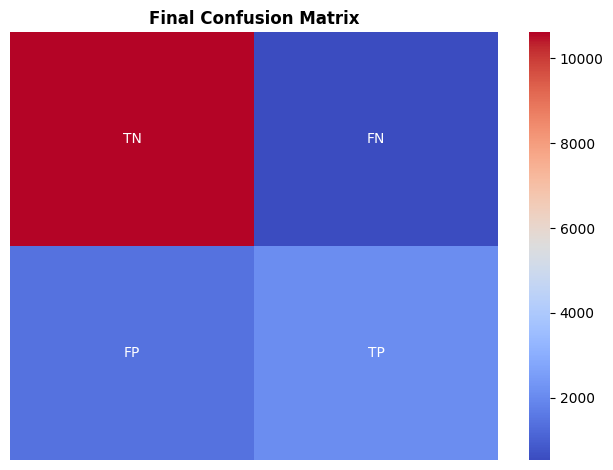

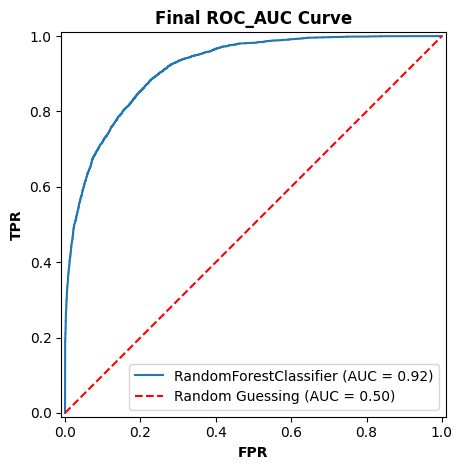

In [71]:
final_acc = accuracy_score(y_true=y_test, y_pred=tuned_rf_clf.predict(X_test))
final_prec = precision_score(y_true=y_test, y_pred=tuned_rf_clf.predict(X_test))
final_rec = recall_score(y_true=y_test, y_pred=tuned_rf_clf.predict(X_test))
final_f1 = f1_score(y_true=y_test, y_pred=tuned_rf_clf.predict(X_test))
final_roc_auc = roc_auc_score(y_true=y_test, y_score=tuned_rf_clf.predict_proba(X_test)[:, 1])

print('*FINAL SCORES:')
print('Accuracy: ', final_acc,
    '\nPrecision: ', final_prec,
    '\nRecall: ', final_rec,
    '\nF1: ', final_f1,
    '\nROC_AUC: ', final_roc_auc, end='\n\n')

sns.heatmap(confusion_matrix(y_true=y_test, y_pred=tuned_rf_clf.predict(X_test)), cmap='coolwarm', annot=[['TN', 'FN'],['FP', 'TP']], fmt='')
plt.title('Final Confusion Matrix', weight='bold')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(estimator=tuned_rf_clf, X=X_test, y=y_test)
plt.title('Final ROC_AUC Curve', weight='bold')
plt.plot([0,1], [0,1], linestyle='--', color='red', label='Random Guessing (AUC = 0.50)')
plt.xlabel('FPR', weight='bold')
plt.ylabel('TPR', weight='bold')
plt.legend()
plt.tight_layout()
plt.show()

##### 2.) Which metric is appropriate for this problem?

> I think f1 and roc_auc metrics are appropriate for this problem because the data is imbalance, so in order to evaluate it I will need f1 metric, and roc_auc metric to know if the model is good even it is imbalance.

###### <span style="font-size: 1.8em;"> What does the confusion matrix tell you about the model's strengths and weaknesses?</span>

>It tells me that it is good on getting true negatives than the positives and it make sense because the data is imbalance, for false negatives and positives it only has small percentage of them.

#### **PART 7: BUILD A COMPLETE PIPELINE**

##### 1.) Preprocesses the original data again by using a column transformer using the same steps from above but merged by a pipeline.

In [65]:
Xf_train = df.loc[X_train.index]
Xf_test = df.loc[X_test.index]

cat_columns = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
num_columns = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

column_transformer = ColumnTransformer(transformers=[('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_columns),
                    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(sparse_output=False)), cat_columns)], remainder='drop')
column_transformer.set_output(transform='pandas')

complete_model = make_pipeline(column_transformer, tuned_rf_clf)
complete_model.fit(Xf_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','workclass','fnlwgt',...,'hours-per-week','native-country','class']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

##### 2.) Gets all the final scores again for the test set to compare the manual preprocessing vs the shortcut preprocessing.

In [66]:
finalpipe_acc = accuracy_score(y_true=y_test, y_pred=complete_model.predict(Xf_test))
finalpipe_prec = precision_score(y_true=y_test, y_pred=complete_model.predict(Xf_test))
finalpipe_rec = recall_score(y_true=y_test, y_pred=complete_model.predict(Xf_test))
finalpipe_f1 = f1_score(y_true=y_test, y_pred=complete_model.predict(Xf_test))
finalpipe_roc_auc = roc_auc_score(y_true=y_test, y_score=complete_model.predict_proba(Xf_test)[:, 1])

print('*FINAL PIPELINE SCORES:')
print('Accuracy: ', finalpipe_acc,
    '\nPrecision: ', finalpipe_prec,
    '\nRecall: ', finalpipe_rec,
    '\nF1: ', finalpipe_f1,
    '\nROC_AUC: ', finalpipe_roc_auc, end='\n\n')

*FINAL PIPELINE SCORES:
Accuracy:  0.8655565413225961 
Precision:  0.7960678488820354 
Recall:  0.5889903023388476 
F1:  0.6770491803278689 
ROC_AUC:  0.9177460638418571



#### **PART 8 - MODEL INTERPRETATION**

##### 1.) Plots the final top 10 features again to interpret the model.

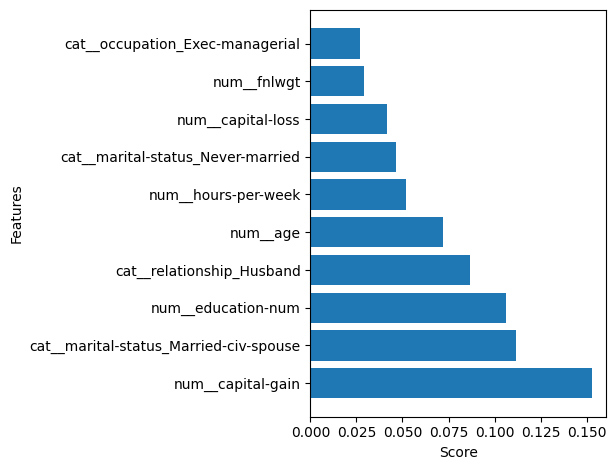

In [72]:
preprocessor = complete_model.named_steps['columntransformer']
transformed_data = preprocessor.transform(Xf_train)
topf_df = pd.DataFrame({'features':transformed_data.columns, 'feature_score':complete_model[-1].feature_importances_.round(6)})
topf_df.sort_values(by='feature_score', ascending=False, inplace=True)
topf_df.drop(index=topf_df.index[10:], inplace=True)

plt.barh(topf_df['features'], topf_df['feature_score'])
plt.xlabel('Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()